# Capstone Two: EDA

#### Clickstream Data for Online Shopping
#### Dataset: https://archive.ics.uci.edu/dataset/553/clickstream+data+for+online+shopping

In [31]:
#Import packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import calendar 
from statsmodels.tsa.seasonal import seasonal_decompose

#Show plots inline
%matplotlib inline

In [33]:
#Import data
df = pd.read_csv('dataset/shopping_data_cleaned.csv', parse_dates=['date'])

In [35]:
#Initial inspection
print(df.shape)
df.head()

(165474, 15)


,year,month,day,order,country,session ID,page 1 (main category),page 2 (clothing model),colour,location,model photography,price,price 2,page,date
0,2008,4,1,1,29,1,1,A13,1,5,1,28.0,2,1,2008-04-01
1,2008,4,1,2,29,1,1,A16,1,6,1,33.0,2,1,2008-04-01
2,2008,4,1,3,29,1,2,B4,10,2,1,52.0,1,1,2008-04-01
3,2008,4,1,4,29,1,2,B17,6,6,2,38.0,2,1,2008-04-01
4,2008,4,1,5,29,1,2,B8,4,3,2,52.0,1,1,2008-04-01


In [37]:
#Checking data types
df.dtypes

year                                int64
month                               int64
day                                 int64
order                               int64
country                             int64
session ID                          int64
page 1 (main category)              int64
page 2 (clothing model)            object
colour                              int64
location                            int64
model photography                   int64
price                             float64
price 2                             int64
page                                int64
date                       datetime64[ns]
dtype: object

In [39]:
#Convert raw codes to descriptive labels
df['cust_country'] = df['country'] \
    .map({1: 'Australia', 2: 'Austria', 3: 'Belgium', 4: 'British Virgin Islands', 5: 'Cayman Islands', 6: 'Christmas Islands',
          7: 'Croatia', 8: 'Cyprus', 9: 'Czech Republic', 10: 'Denmark', 11: 'Estonia', 12: 'unidentified', 13: 'Faroe Islands',
          14: 'Findland', 15: 'France', 16: 'Germany', 17: 'Greece', 18: 'Hungary', 19: 'Iceland', 20: 'India', 21: 'Ireland',
          22:  'Italy', 23: 'Latvia', 24: 'Lithuania', 25: 'Luxembourg', 26: 'Mexico', 27: 'Netherlands', 28: 'Norway', 29: 'Poland',
          30: 'Portugal', 31: 'Romania', 32: 'Russia', 33: 'San Marino', 34: 'Slovakia', 35: 'Slovenia', 36: 'Spain', 37: 'Sweden',
          38: 'Switzerland', 39: 'Ukraine', 40: 'United Arab Emirates', 41: 'United Kingdom', 42: 'USA', 43: 'biz (*.biz)',
          44: 'com (*.com)', 45: 'int (*.int)', 46: 'net (*.net)', 47: 'org (*.org)'})

df['main_category'] = df['page 1 (main category)'] \
    .map({1: 'trousers', 2: 'skirt',3: 'blouse',4: 'sale'})

df['product_colour'] = df['colour'] \
    .map({1: 'beige', 2: 'black', 3: 'blue', 4: 'brown', 5: 'burgundy', 6: 'gray', 7: 'green', 8: 'navy blue', 9: 'of many colours',
          10: 'olive', 11: 'pink', 12: 'red', 13: 'violet', 14: 'white'})

df['page_location'] = df['location'] \
    .map({1: 'top left', 2: 'top in the middle', 3: 'top right', 4: 'bottom left', 5: 'bottom in the middle', 6: 'bottom right'})

df['model_view'] = df['model photography'] \
    .map({1: 'en face', 2: 'profile'})

df['price2_label'] = df['price 2'] \
    .map({1: 'Above Avg', 2: 'Below Avg'})

In [41]:
#Convert columns to category dtype
df['cust_country'] = df['cust_country'].astype('category')
df['main_category']  = df['main_category'].astype('category')
df['page 2 (clothing model)'] = df['page 2 (clothing model)'].astype('category')
df['product_colour'] = df['product_colour'].astype('category')
df['page_location'] = df['page_location'].astype('category')
df['model_view'] = df['model_view'].astype('category')
df['price2_label'] = df['price2_label'].astype('category')
df['page'] = df['page'].astype('category')

#Check for conversion
print(df.dtypes[['cust_country', 'main_category', 'page 2 (clothing model)', 'product_colour', 'page_location', 'model_view', 'price2_label', 'page']])

cust_country               category
main_category              category
page 2 (clothing model)    category
product_colour             category
page_location              category
model_view                 category
price2_label               category
page                       category
dtype: object


In [43]:
#Numeric summary of price column
df['price'].describe()

count    165474.000000
mean         43.802507
std          12.548131
min          18.000000
25%          33.000000
50%          43.000000
75%          52.000000
max          82.000000
Name: price, dtype: float64

In [45]:
#Frequency counts of categorical features
df['main_category'].value_counts()

main_category
trousers    49742
sale        38747
blouse      38577
skirt       38408
Name: count, dtype: int64

In [47]:
#Check value counts for different clothing items
df['page 2 (clothing model)'].value_counts()

page 2 (clothing model)
B4     3579
A2     3013
A11    2789
P1     2681
B10    2566
       ... 
P66      46
P79       2
P22       2
P28       1
P54       1
Name: count, Length: 217, dtype: int64

In [49]:
#Check value counts by country
df['cust_country'].value_counts()

cust_country
Poland                    133963
Czech Republic             18003
Lithuania                   4091
net (*.net)                 2522
com (*.com)                 1385
Germany                      834
Ireland                      811
Slovakia                     716
United Kingdom               684
Belgium                      256
Netherlands                  227
unidentified                 210
USA                          170
Sweden                       163
Denmark                      152
Italy                        144
Romania                      144
Norway                       139
Switzerland                  137
France                       125
Estonia                      115
Luxembourg                    71
Austria                       58
Russia                        49
Latvia                        46
Findland                      43
Ukraine                       34
biz (*.biz)                   31
Iceland                       29
Greece                        

In [51]:
#Check break down of prices above or below average
df['price2_label'].value_counts()

price2_label
Above Avg    84695
Below Avg    80779
Name: count, dtype: int64

## Univariate Distribution Analysis

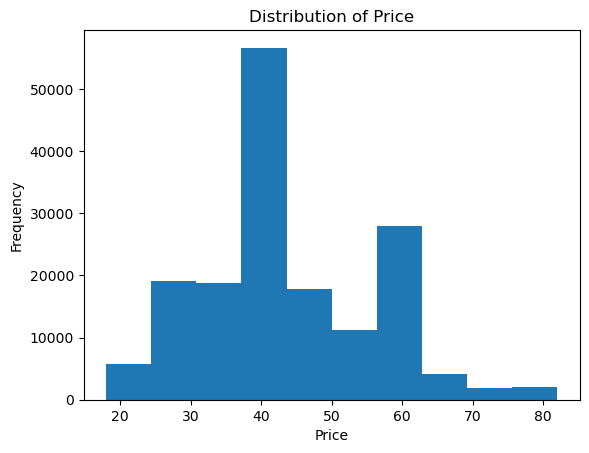

In [54]:
#Histogram of price to show distribution
plt.figure()
plt.hist(df['price'])
plt.title('Distribution of Price')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()

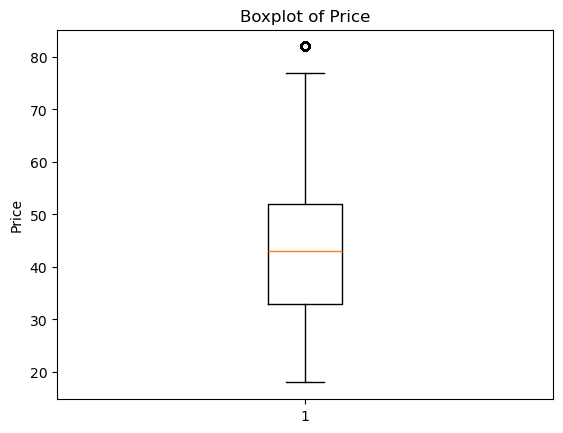

In [56]:
#Boxplot of price to highlight outliers
plt.figure()
plt.boxplot(df['price'])
plt.title('Boxplot of Price')
plt.ylabel('Price')
plt.show()

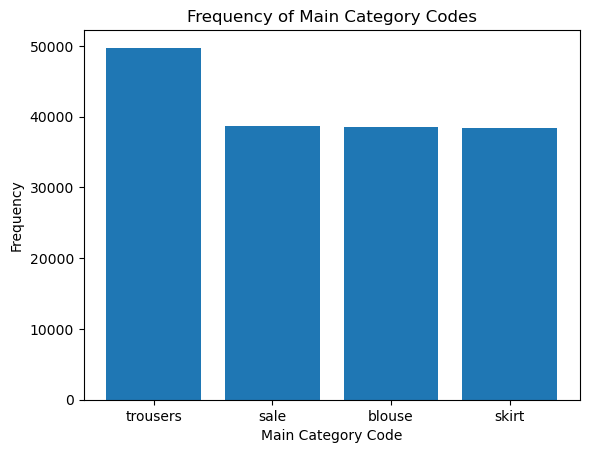

In [58]:
#Bar chart of main clothing categories
category_counts = df['main_category'].value_counts()
plt.figure()
plt.bar(category_counts.index.astype(str), category_counts.values)
plt.title('Frequency of Main Category Codes')
plt.xlabel('Main Category Code')
plt.ylabel('Frequency')
plt.show()

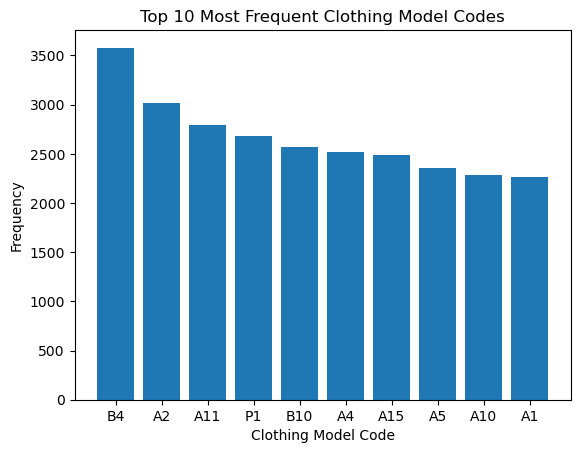

In [60]:
#Bar chart of top 10 most frequent clothing model codes
model_counts = df['page 2 (clothing model)'].value_counts().nlargest(10)
plt.figure()
plt.bar(model_counts.index.astype(str), model_counts.values)
plt.title('Top 10 Most Frequent Clothing Model Codes')
plt.xlabel('Clothing Model Code')
plt.ylabel('Frequency')
plt.show()

## Outlier Dectection

In [63]:
#Compute Q1, Q3, and IQR of price
q1  = df['price'].quantile(0.25)
q3  = df['price'].quantile(0.75)
iqr = q3 - q1

#Define bounds
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

#Extract outliers
outliers = df[(df['price'] < lower_bound) | (df['price'] > upper_bound)]

print(f"Outliers found: {len(outliers)}")
outliers.head()

Outliers found: 1923


,year,month,day,order,country,session ID,page 1 (main category),page 2 (clothing model),colour,location,...,price,price 2,page,date,cust_country,main_category,product_colour,page_location,model_view,price2_label
115,2008,4,1,7,9,18,1,A9,3,3,...,82.0,1,1,2008-04-01,Czech Republic,trousers,blue,top right,en face,Above Avg
237,2008,4,1,3,9,40,1,A9,3,3,...,82.0,1,1,2008-04-01,Czech Republic,trousers,blue,top right,en face,Above Avg
321,2008,4,1,31,9,49,1,A9,3,3,...,82.0,1,1,2008-04-01,Czech Republic,trousers,blue,top right,en face,Above Avg
380,2008,4,1,5,29,58,1,A9,3,3,...,82.0,1,1,2008-04-01,Poland,trousers,blue,top right,en face,Above Avg
426,2008,4,1,4,24,67,1,A9,3,3,...,82.0,1,1,2008-04-01,Lithuania,trousers,blue,top right,en face,Above Avg


In [65]:
outliers['price'].value_counts()

price
82.0    1923
Name: count, dtype: int64

## Bivariate Analysis

In [68]:
#Average price of product grouped by whether the price of a particular product
#is higher than the average price for the entire product category
df.groupby('price2_label')['price'].mean()

/var/folders/fx/hgr0qjbs13q4rlhs7k4n4ktm0000gn/T/ipykernel_26263/2304315569.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('price2_label')['price'].mean()


price2_label
Above Avg    52.915414
Below Avg    34.247824
Name: price, dtype: float64

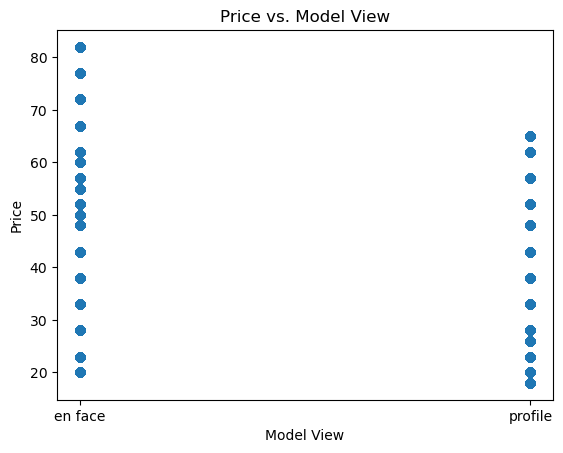

In [70]:
#Scatterplot of Model View vs Price
plt.figure()
plt.scatter(
    df['model_view'], 
    df['price'], 
    alpha=0.6
)
plt.title('Price vs. Model View')
plt.xlabel('Model View')
plt.ylabel('Price')
plt.show()

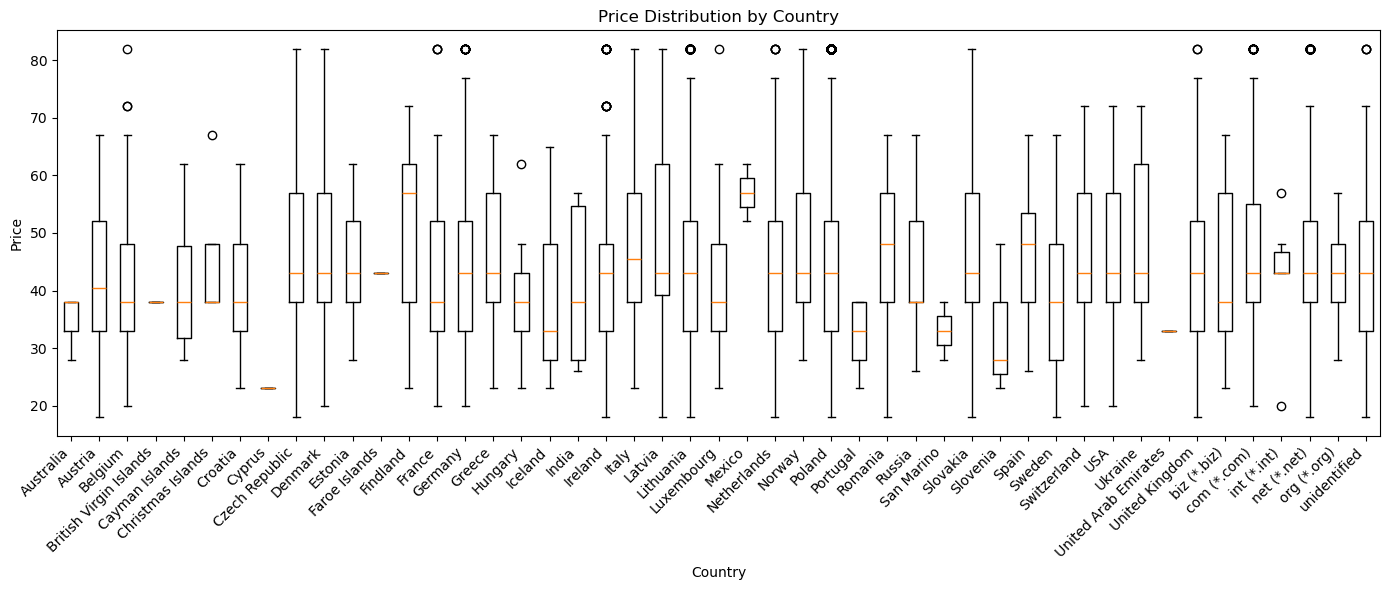

In [71]:
#Boxplot of Price Distribution by Country

countries = sorted(df['cust_country'].unique())
price_data = [df.loc[df['cust_country'] == c, 'price'].dropna() for c in countries]

countries = sorted(df['cust_country'].unique())

plt.figure(figsize=(14, 6))                 
price_data = [df.loc[df['cust_country']==c, 'price'] for c in countries]
plt.boxplot(price_data, tick_labels=countries, showfliers=True)

plt.title('Price Distribution by Country')
plt.xlabel('Country')
plt.ylabel('Price')

plt.xticks(rotation=45, ha='right')           
plt.tight_layout()                            
plt.show()

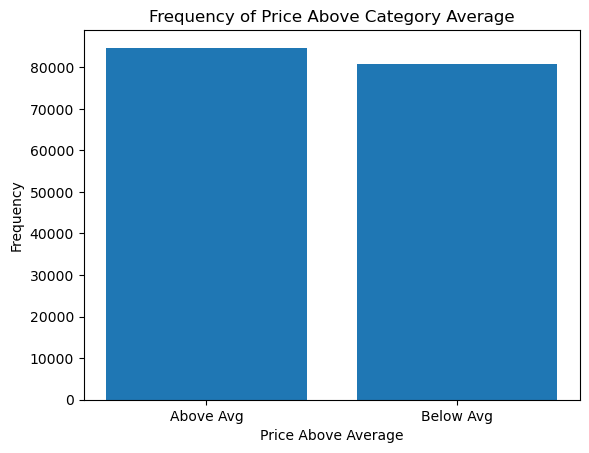

In [74]:
#Bar plot of Freqency of Price Below vs Above Category Average

price2_counts = df['price2_label'].value_counts()

plt.figure()
plt.bar(price2_counts.index, price2_counts.values)
plt.title('Frequency of Price Above Category Average')
plt.xlabel('Price Above Average')
plt.ylabel('Frequency')
plt.show()

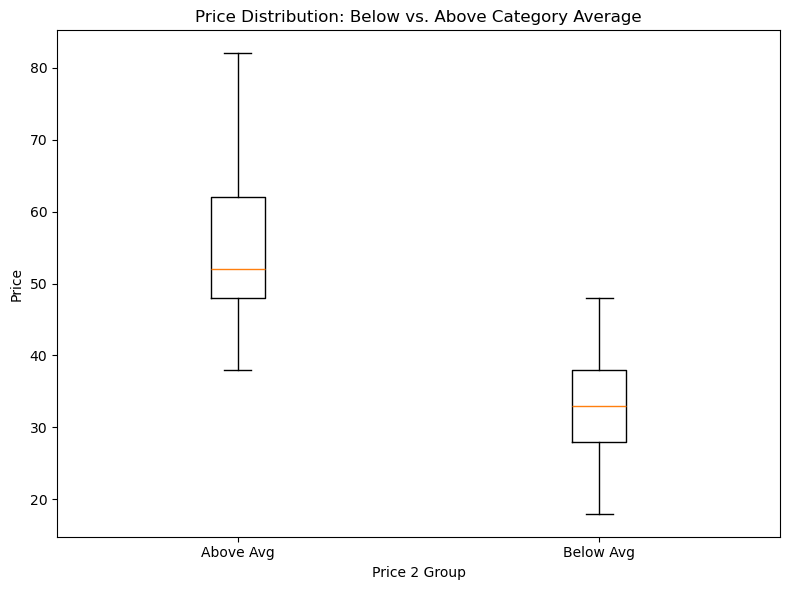

In [76]:
#Boxplot of Price Below vs Above Category Average
groups = [
    df.loc[df['price2_label'] == 'Above Avg', 'price'].dropna(),
    df.loc[df['price2_label'] == 'Below Avg', 'price'].dropna()
]
labels = ['Above Avg', 'Below Avg']

plt.figure(figsize=(8, 6))
plt.boxplot(groups, tick_labels=labels, showfliers=True)
plt.title('Price Distribution: Below vs. Above Category Average')
plt.xlabel('Price 2 Group')
plt.ylabel('Price')
plt.tight_layout()
plt.show()

/var/folders/fx/hgr0qjbs13q4rlhs7k4n4ktm0000gn/T/ipykernel_26263/491754793.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(['cust_country', 'price2_flag'])


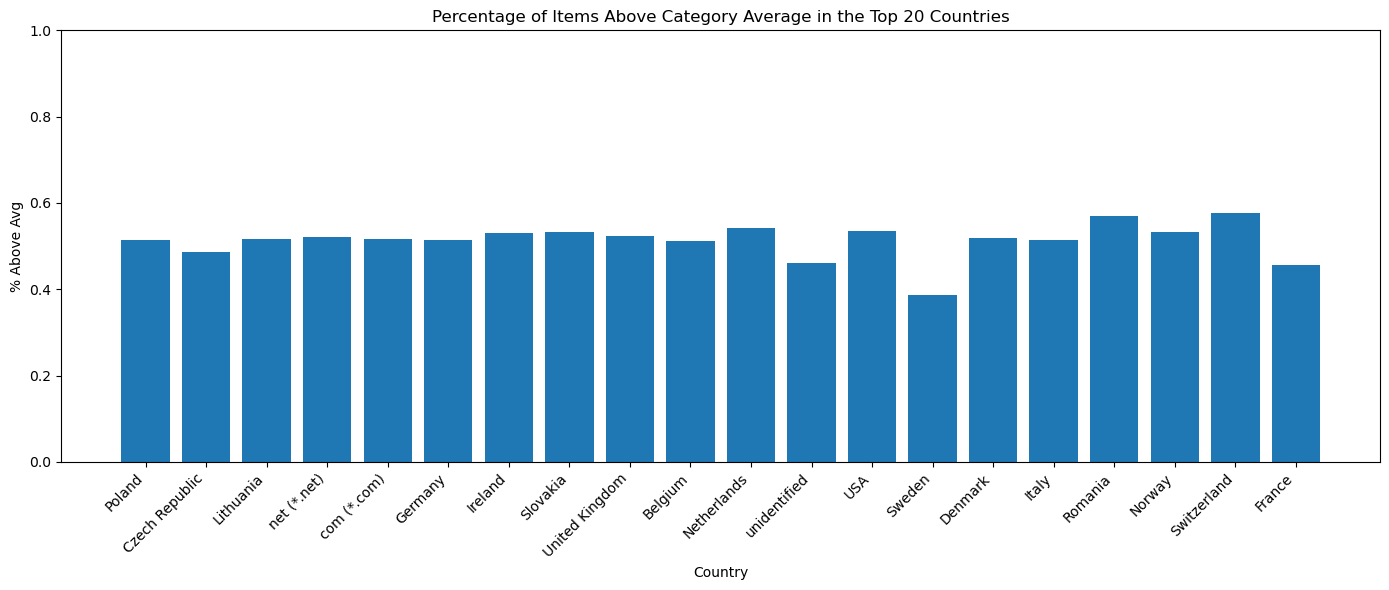

In [78]:
#Create bar graph of top 20 countries with above avg purchases
df['price2_flag'] = df['price 2'].astype(int)

top20 = df['cust_country'].value_counts().nlargest(20).index

df_top20 = df[df['cust_country'].isin(top20)]

counts = (
    df_top20
    .groupby(['cust_country', 'price2_flag'])
    .size()
    .unstack(fill_value=0)
    .rename(columns={1: 'Above Avg', 2: 'Below Avg'})
)

counts['Pct Above Avg'] = counts['Above Avg'] / (counts['Below Avg'] + counts['Above Avg'])

counts = counts.reindex(top20)

# 8. Plot
plt.figure(figsize=(14, 6))
plt.bar(counts.index.astype(str), counts['Pct Above Avg'])
plt.title('Percentage of Items Above Category Average in the Top 20 Countries')
plt.xlabel('Country')
plt.ylabel('% Above Avg')
plt.ylim(0, 1)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Time Series Exploration

In [81]:
#Calculate daily and weekly revenue
daily_revenue = (
    df
    .groupby(df['date'].dt.date)['price']
    .sum()
    .reset_index(name='daily_revenue')
)

weekly_revenue = (
    df
    .set_index('date')['price']
    .resample('W-SUN')
    .sum()
    .reset_index(name='weekly_revenue')
)

print(daily_revenue.head())
print(weekly_revenue.head())

         date  daily_revenue
0  2008-04-01       139570.0
1  2008-04-02       150387.0
2  2008-04-03        81466.0
3  2008-04-04        78843.0
4  2008-04-05        66579.0
        date  weekly_revenue
0 2008-04-06        574376.0
1 2008-04-13        469534.0
2 2008-04-20        482893.0
3 2008-04-27        380332.0
4 2008-05-04        351924.0


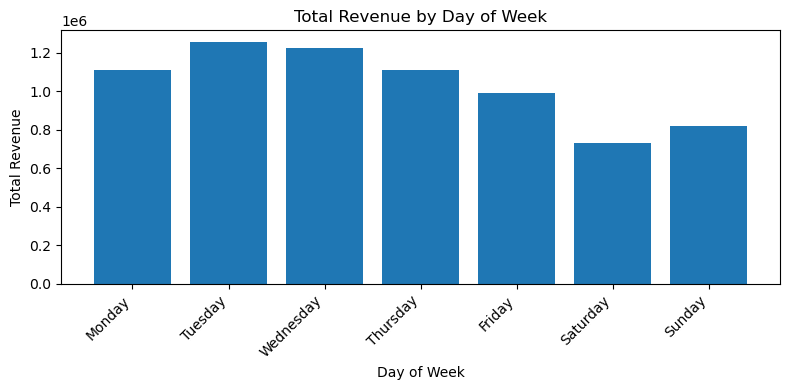

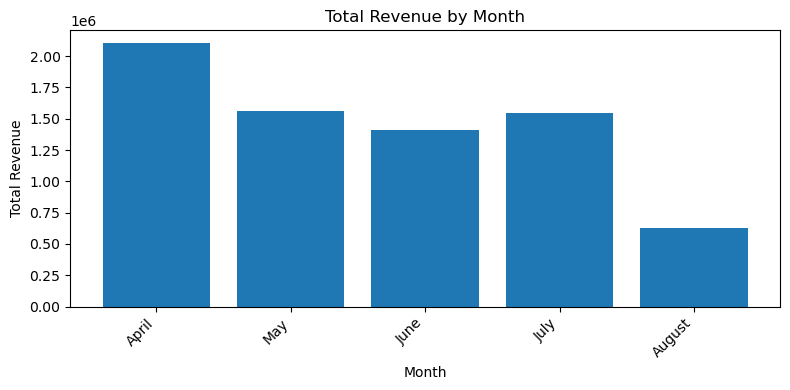

In [83]:
#Plot total revenue by day of week
dow = df.groupby(df['date'].dt.day_name())['price'].sum()
dow = dow.reindex([
    'Monday','Tuesday','Wednesday',
    'Thursday','Friday','Saturday','Sunday'
])

plt.figure(figsize=(8, 4))
plt.bar(dow.index, dow.values)
plt.title('Total Revenue by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Total Revenue')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

#Plot total revenue by month
monthly = df.groupby(df['date'].dt.month)['price'].sum()
monthly.index = [calendar.month_name[m] for m in monthly.index]

plt.figure(figsize=(8, 4))
plt.bar(monthly.index, monthly.values)
plt.title('Total Revenue by Month')
plt.xlabel('Month')
plt.ylabel('Total Revenue')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Session and Conversion Metrics

In [86]:
#Calculate total unique sessions and sessions per day
total_sessions = df['session ID'].nunique()
print(f"Total unique sessions: {total_sessions}")

sessions_per_day = (
    df
    .groupby(df['date'].dt.date)['session ID']
    .nunique()
    .reset_index(name='sessions')
)

print(sessions_per_day)

Total unique sessions: 24026
           date  sessions
0    2008-04-01       477
1    2008-04-02       480
2    2008-04-03       276
3    2008-04-04       266
4    2008-04-05       199
..          ...       ...
130  2008-08-09       136
131  2008-08-10       128
132  2008-08-11       178
133  2008-08-12       187
134  2008-08-13        21

[135 rows x 2 columns]


In [88]:
#Calculate page view per session and summarize
views_per_session = df.groupby('session ID').size()

average_views = views_per_session.mean()
print(f"Average page views per session: {average_views:.2f}")

print(views_per_session.describe())

Average page views per session: 6.89
count    24026.000000
mean         6.887289
std          8.995161
min          1.000000
25%          2.000000
50%          4.000000
75%          8.000000
max        195.000000
dtype: float64


## Feature Engineering

In [91]:
#Create day of week column
df['day_of_week'] = df['date'].dt.day_name()

print(df[['date', 'day_of_week']].head())

        date day_of_week
0 2008-04-01     Tuesday
1 2008-04-01     Tuesday
2 2008-04-01     Tuesday
3 2008-04-01     Tuesday
4 2008-04-01     Tuesday


In [93]:
#Create subcategory thtat combines main category and clothing model number
df['subcategory'] = (
    df['main_category'].astype(str)
    + ' - '
    + df['page 2 (clothing model)'].astype(str)
)

df['subcategory'] = df['subcategory'].astype('category')

print(df[['main_category', 'page 2 (clothing model)', 'subcategory']].head())

  main_category page 2 (clothing model)     subcategory
0      trousers                     A13  trousers - A13
1      trousers                     A16  trousers - A16
2         skirt                      B4      skirt - B4
3         skirt                     B17     skirt - B17
4         skirt                      B8      skirt - B8


## Visualization and Storytelling

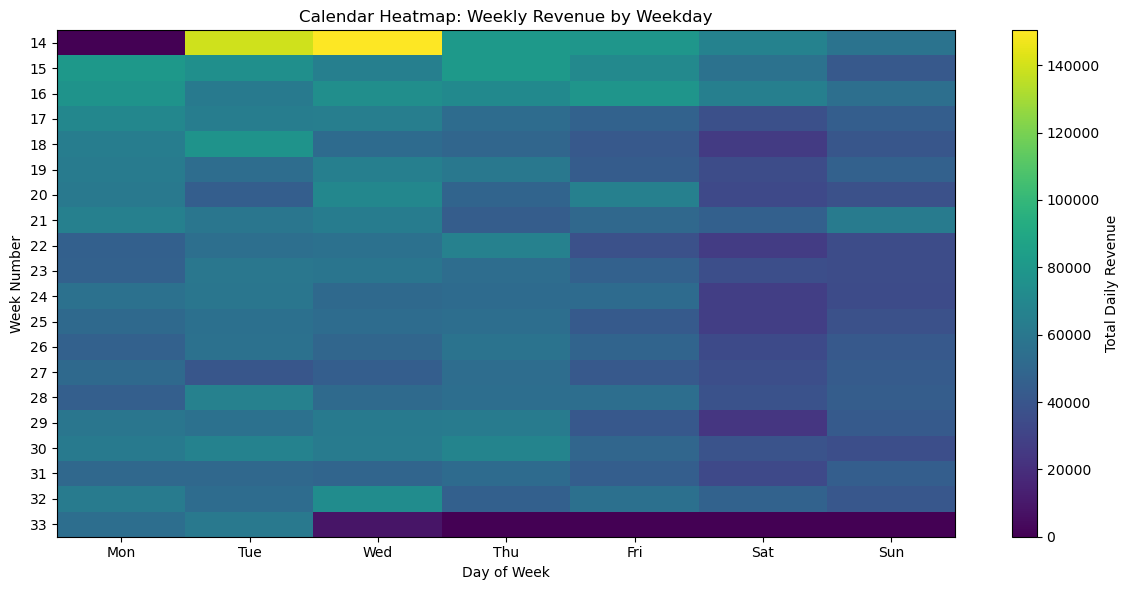

In [96]:
#Calendar heatmap of daily revenue

df['date'] = pd.to_datetime(df['date'])
df['week'] = df['date'].dt.isocalendar().week
df['dow']  = df['date'].dt.weekday

cal = df.groupby(['week','dow'])['price'] \
        .sum() \
        .unstack(fill_value=0)

plt.figure(figsize=(12, 6))
plt.imshow(cal, interpolation='none', aspect='auto')
plt.colorbar(label='Total Daily Revenue')
plt.xticks(range(7), ['Mon','Tue','Wed','Thu','Fri','Sat','Sun'])
plt.yticks(range(len(cal.index)), cal.index)
plt.title('Calendar Heatmap: Weekly Revenue by Weekday')
plt.xlabel('Day of Week')
plt.ylabel('Week Number')
plt.tight_layout()
plt.show()

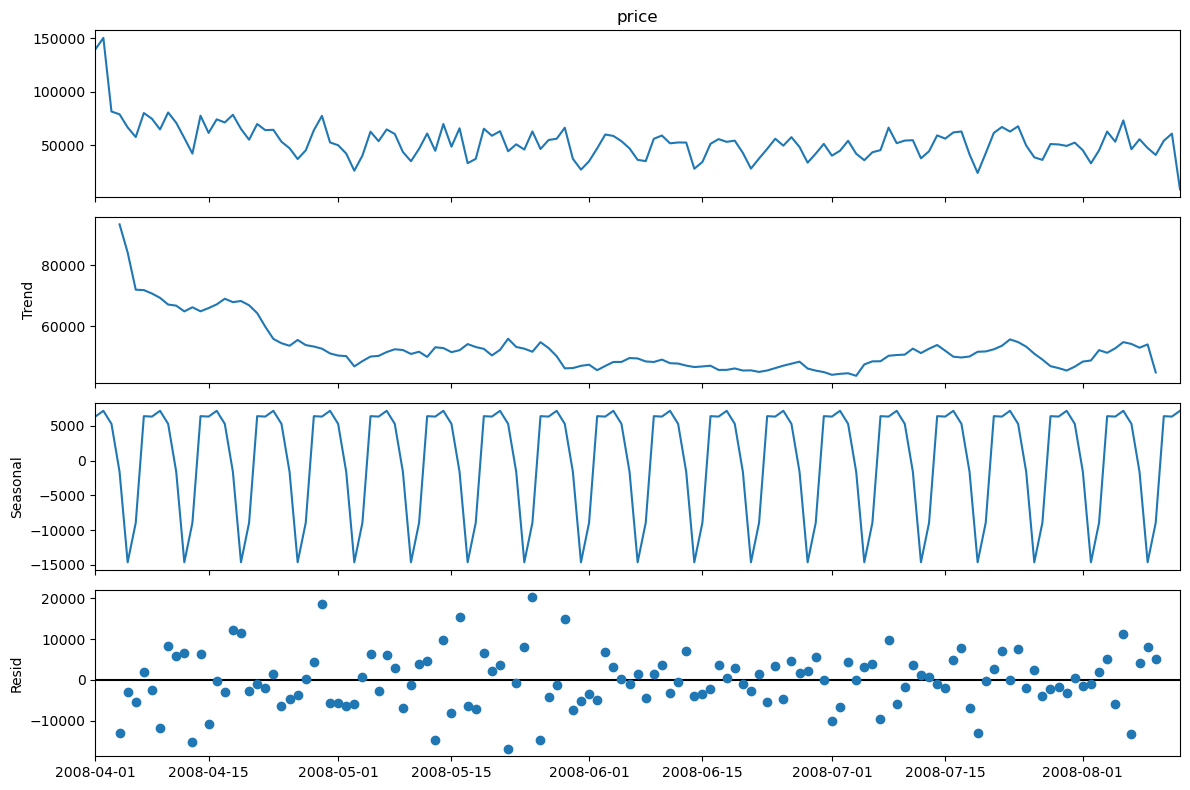

In [98]:
#Create time series decomponsition of daily revenue
df['date'] = pd.to_datetime(dict(
    year = df['year'],
    month= df['month'],
    day  = df['day']
))

df = df.set_index('date')

daily_revenue = df['price'].resample('D').sum()

decomp = seasonal_decompose(daily_revenue, model='additive', period=7)

# Plot
fig = decomp.plot()
fig.set_size_inches(12, 8)
plt.tight_layout()
plt.show()

                 count       mean  median        std
product_colour                                      
olive             3579  52.000000    52.0   0.000000
red               8830  50.429219    52.0  11.232937
blue             29259  49.280427    43.0  14.635571
pink              5292  48.944822    48.0   8.972942
black            29764  46.987905    43.0  11.722361
violet            6295  41.875933    48.0  11.311813
gray             17476  40.566491    38.0  12.293259
of many colours  13531  40.488656    43.0  11.497180
brown            16517  40.115881    38.0  10.635237
white            15939  40.053705    38.0   9.655738
beige             7785  39.862171    38.0  12.012418
burgundy          1667  38.539292    33.0   8.637566
green             6876  35.014252    33.0   6.669361
navy blue         2664  30.246622    28.0   5.353763


/var/folders/fx/hgr0qjbs13q4rlhs7k4n4ktm0000gn/T/ipykernel_26263/3923184478.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby('product_colour')['price']


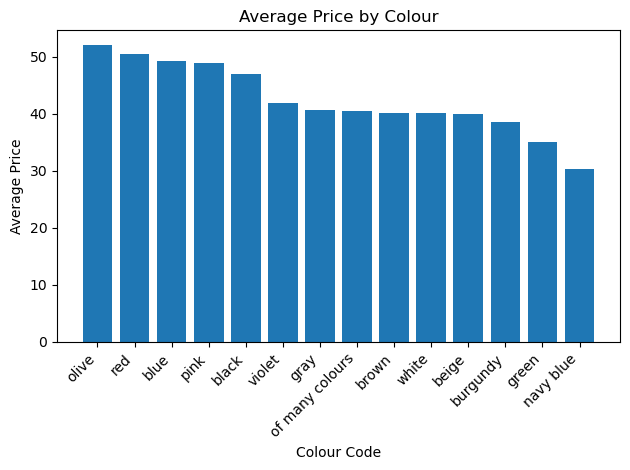

<Figure size 1000x600 with 0 Axes>

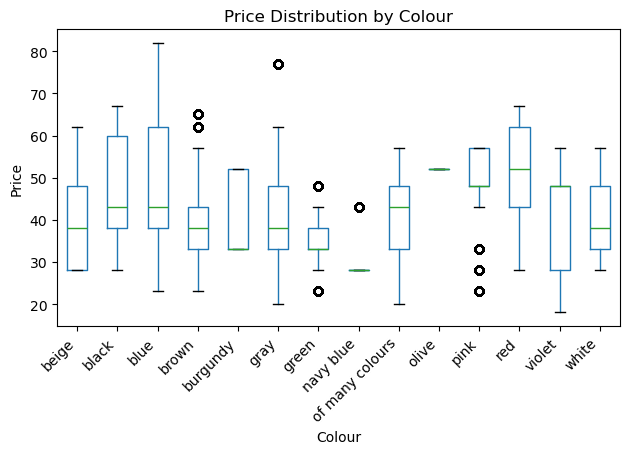

In [100]:
#Calculate summary statistics by colour
colour_stats = (
    df
    .groupby('product_colour')['price']
    .agg(count='count', mean='mean', median='median', std='std')
    .sort_values('mean', ascending=False)
)
print(colour_stats)

#Bar plot of price distrbution by colour
plt.bar(colour_stats.index.astype(str), colour_stats['mean'])
plt.title('Average Price by Colour')
plt.xlabel('Colour Code')
plt.ylabel('Average Price')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

#Boxplot of price distribution by colour
plt.figure(figsize=(10, 6))
df.boxplot(column='price', by='product_colour', grid=False)
plt.title('Price Distribution by Colour')
plt.suptitle('')  # remove the automatic title
plt.xlabel('Colour')
plt.ylabel('Price')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

page
1    93452
2    41037
3    19301
4     8861
5     2823
Name: count, dtype: int64


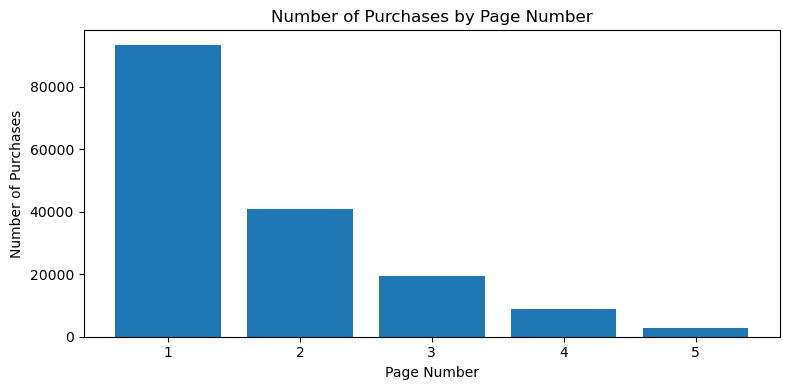

In [108]:
#Count values of purchaes by page
page_purchase_counts = df['page'].value_counts().sort_index()

#Display the counts
print(page_purchase_counts)

#Plot results as bar chart
plt.figure(figsize=(8, 4))
plt.bar(page_purchase_counts.index.astype(str), page_purchase_counts.values)
plt.title('Number of Purchases by Page Number')
plt.xlabel('Page Number')
plt.ylabel('Number of Purchases')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

page_location
bottom in the middle    27783
bottom left             27377
bottom right            20743
top in the middle       33383
top left                34532
top right               21656
Name: count, dtype: int64


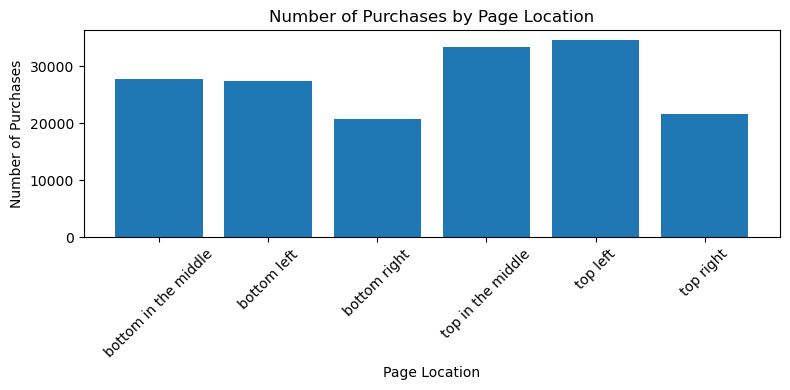

In [112]:
#Count values of purchaes by page location
loc_purchase_counts = df['page_location'].value_counts().sort_index()

#Display the counts
print(loc_purchase_counts)

#Plot results as bar chart
plt.figure(figsize=(8, 4))
plt.bar(loc_purchase_counts.index.astype(str), loc_purchase_counts.values)
plt.title('Number of Purchases by Page Location')
plt.xlabel('Page Location')
plt.ylabel('Number of Purchases')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

model_view
en face    122439
profile     43035
Name: count, dtype: int64


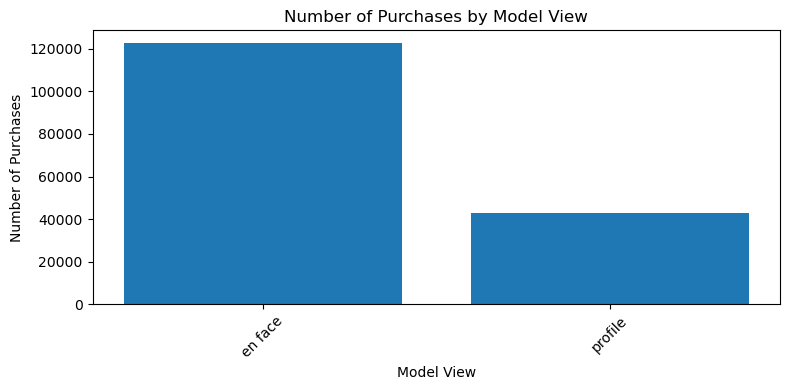

In [128]:
#Count values of purchaes by model view
model_purchase_counts = df['model_view'].value_counts().sort_index()

#Display the counts
print(model_purchase_counts)

#Plot results as bar chart
plt.figure(figsize=(8, 4))
plt.bar(model_purchase_counts.index.astype(str), model_purchase_counts.values)
plt.title('Number of Purchases by Model View')
plt.xlabel('Model View')
plt.ylabel('Number of Purchases')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Based on the exploration of data, some relationships are starting to emerge.  It appears that when an item is displayed on the first page is it more likely to be purchased.  It also appears that when an item appears in the top middle and top left of a page it is more likely to be purchased.

Another observed trend is that items that are olive, red, blue, pink, and black have an average price that is higher than the overall mean price of \$43.80.

We also observed that there are 1,923 items with the outlier price of \$82.00.

Given that business in our case study is based in Poland, it is not surprising that the majority of purchases came from customer is Poland.  Because we do not have a large number of purchases from many other countries, it does not make sense to explore subgroups based on country.

### Possible Hypotheses to Explore

1. When items are displayed in the bottom middle or top left of a page they are more likely to be purchsed.
2. Customers are willing to pay more for items that are olive, red, blue, pink, or black.
3. When the model is en face customers are more likely to purchase these items.